# 📊 Comprehensive Fitting Pipeline (860 cm⁻¹)

This notebook is organized to compare three different fitting methods on the 860 cm⁻¹ wavenumber data:
1. **Complex Hankel Transform (CHT)**: The $k$-space method from the 2015 Nature Materials paper.
2. **Real Space Hankel**: Fitting the spatial amplitude directly using the Hankel model.
3. **Real Space $1/\sqrt{x}$**: Fitting the spatial amplitude directly using an inverse square-root envelope.

All results are extracted and automatically logged into `data/fitting_results_comparison.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import scipy.special as sp
import sys
sys.path.append('.')
import nanoftir_Shizhe as nanoftir
import importlib
importlib.reload(nanoftir)
%matplotlib widget
# 🎨 APS Plotting Style Configuration
plt.rcParams.update({
    'font.size': 12, 'font.family': 'Arial',
    'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True,
    'ytick.right': True
})

## 1. Batch Data Alignment & Initialization
Here we load all 15 wavenumbers, visualize them in an unaligned state, apply a customizable edge shift via `align_dict`, and visualize the aligned result. Once aligned, we select one target wavenumber to pass to the downstream fitting pipelines.

Saved to figures/waterfall_unaligned.png


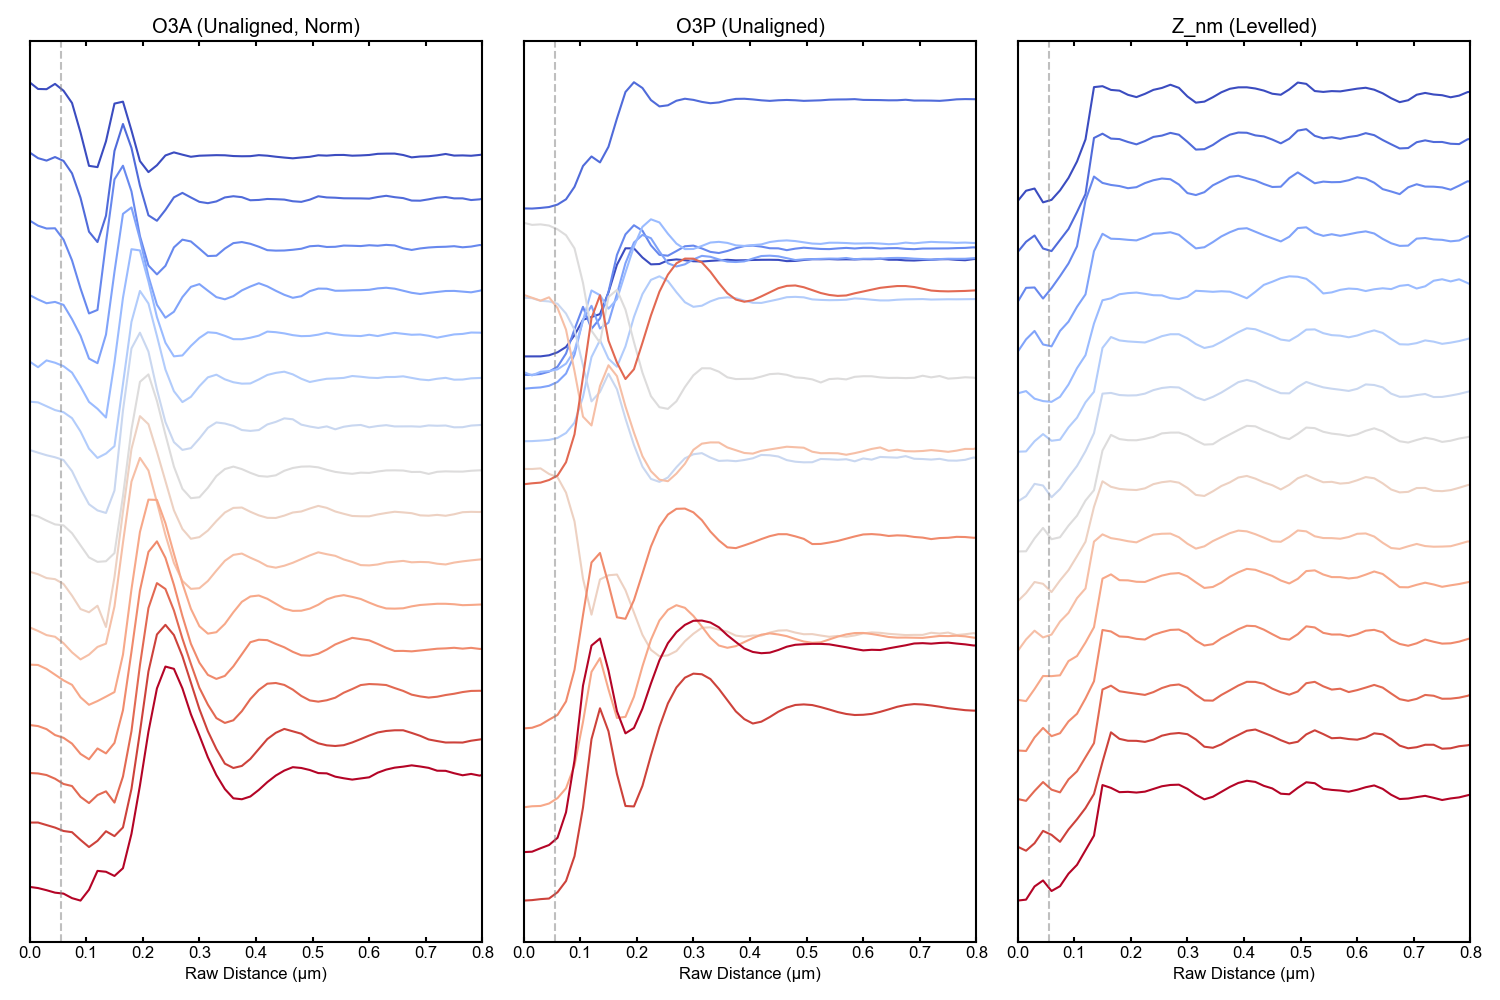

In [2]:
import glob
import re
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = 'data/graphene_3x1'
file_paths = glob.glob(f'{data_dir}/*_AVG_lp1.csv')

# ==========================================
# 🌟 VISUALIZATION SETTINGS (Tweak these!) 🌟
# ==========================================
normalize_A = True   # Normalize Amplitude to 1
normalize_P = False  # Normalize Phase to 1

# ⬇️ 缩小这些 offset 可以让线挨得更近，从而显得 Peak 更高、起伏更夸张！
offset_A = 0.15  # Amplitude 的垂直间距 (建议范围: 0.1 ~ 0.5)
offset_P = 0.4   # Phase 的垂直间距
offset_Z = 1.0   # Z 地形的垂直间距
# ==========================================

# Extract wavenumbers and sort
def get_wn(p):
    match = re.search(r'(\d+)cm-1', p)
    return int(match.group(1)) if match else 0

file_paths = sorted(file_paths, key=get_wn, reverse=True)
wn_list = [f"{get_wn(p)}cm-1" for p in file_paths]

# Load raw data and apply custom Z correction
raw_data_dict = {}
for wn, path in zip(wn_list, file_paths):
    df = pd.read_csv(path)
    df['Z_nm_custom'] = df['Z_nm_corrected'] - df['Z_nm_corrected'].min()
    raw_data_dict[wn] = df

# Plot 1x3 Unaligned Waterfall
fig, axs = plt.subplots(1, 3, figsize=(15, 10))
colors = cm.coolwarm(np.linspace(0, 1, len(wn_list)))

for i, wn in enumerate(wn_list):
    df = raw_data_dict[wn]
    x = df['distance_nm'] / 1000.0  # to um
    
    a_data = df['O3A']
    p_data = df['O3P']
    
    if normalize_A: a_data = a_data / a_data.max()
    if normalize_P: p_data = p_data / p_data.max()
    
    axs[0].plot(x, a_data - offset_A * i, color=colors[i], lw=1.5)
    axs[1].plot(x, p_data - offset_P * i, color=colors[i], lw=1.5)
    axs[2].plot(x, df['Z_nm_custom'] - offset_Z * i, color=colors[i], lw=1.5)

axs[0].set_title('O3A (Unaligned' + (', Norm)' if normalize_A else ')'))
axs[1].set_title('O3P (Unaligned' + (', Norm)' if normalize_P else ')'))
axs[2].set_title('Z_nm (Levelled)')

for ax in axs:
    ax.set_xlabel('Raw Distance (μm)')
    ax.set_yticks([]) # Clean waterfall look
    ax.axvline(0.055, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(0,0.8)

plt.tight_layout()

# Save to figures folder
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/waterfall_unaligned.png', dpi=300, bbox_inches='tight')
print("Saved to figures/waterfall_unaligned.png")


Saved to figures/waterfall_aligned.png


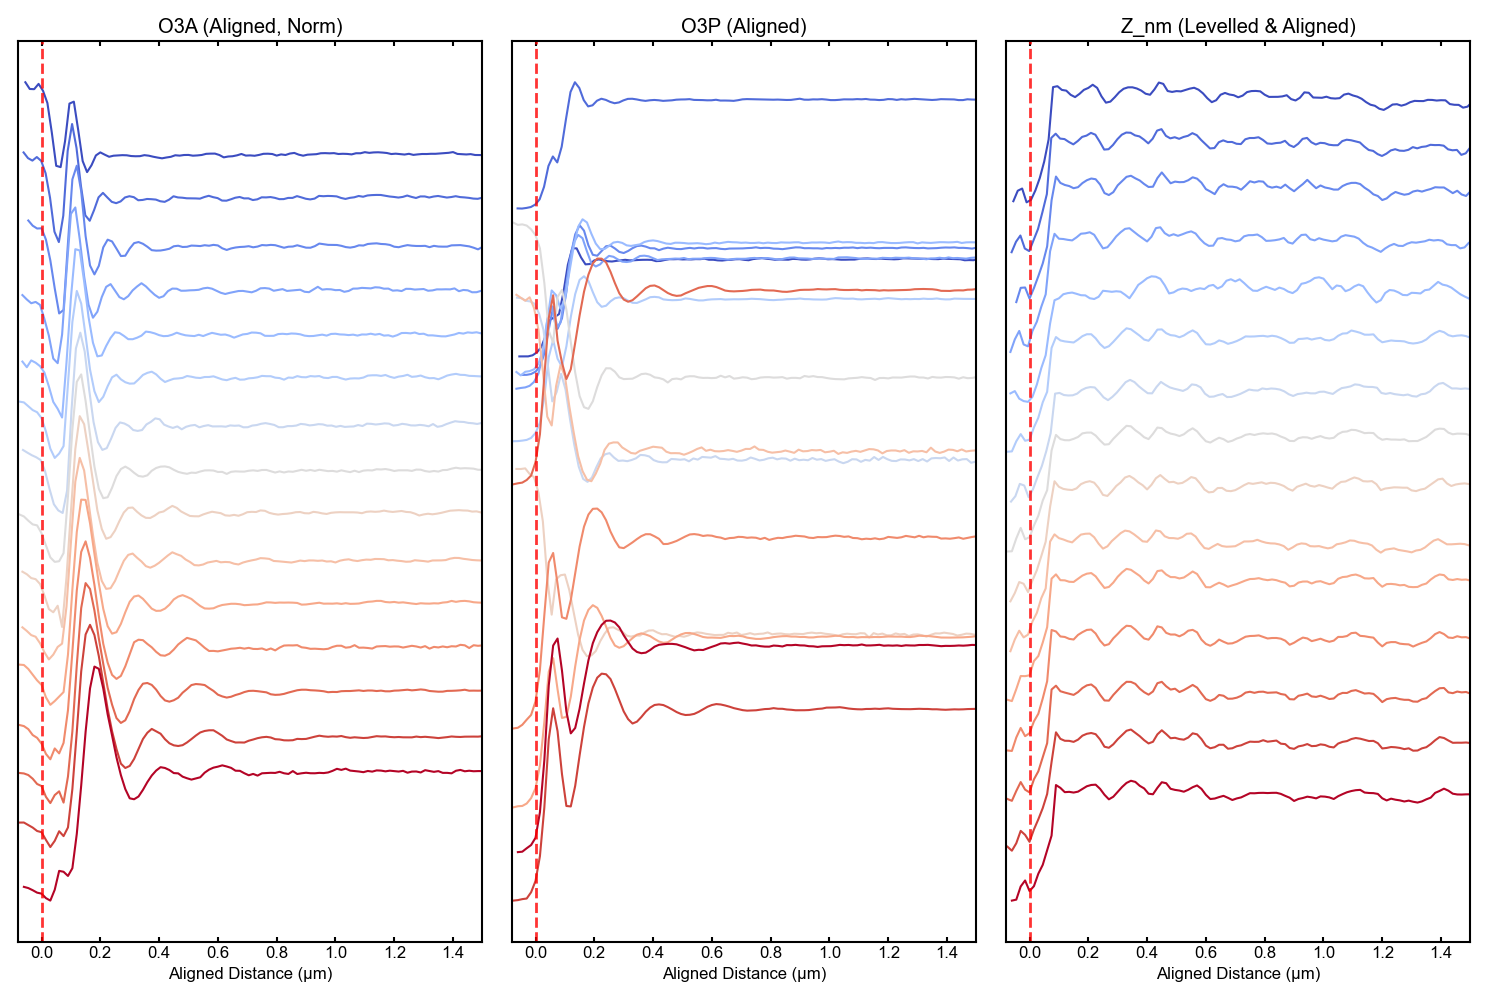

In [3]:
# 🌟 Interactive Alignment Dictionary 🌟
# Modify the shift value (in nm) for any wavenumber to manually align its edge to X=0.
align_dict = {
    '860cm-1': 60,
    '870cm-1': 75,
    '880cm-1': 75,
    '890cm-1': 75,
    '900cm-1': 75,
    '911cm-1': 65,
    '920cm-1': 65,
    '930cm-1': 75,
    '941cm-1': 63,
    '950cm-1': 75,
    '960cm-1': 65,
    '970cm-1': 65,
    '980cm-1': 45,
    '991cm-1': 61,
    '1000cm-1': 55,
}

# Apply alignment
aligned_data_dict = {}
for wn in wn_list:
    df_aligned = raw_data_dict[wn].copy()
    shift_nm = align_dict[wn]
    df_aligned['distance_um'] = (df_aligned['distance_nm'] - shift_nm) / 1000.0
    aligned_data_dict[wn] = df_aligned

# Plot 1x3 Aligned Waterfall
fig, axs = plt.subplots(1, 3, figsize=(15, 10))

for i, wn in enumerate(wn_list):
    df = aligned_data_dict[wn]
    x = df['distance_um']
    
    a_data = df['O3A']
    p_data = df['O3P']
    
    if normalize_A: a_data = a_data / a_data.max()
    if normalize_P: p_data = p_data / p_data.max()
    
    axs[0].plot(x, a_data - offset_A * i, color=colors[i], lw=1.5)
    axs[1].plot(x, p_data - offset_P * i, color=colors[i], lw=1.5)
    axs[2].plot(x, df['Z_nm_custom'] - offset_Z * i, color=colors[i], lw=1.5)

axs[0].set_title('O3A (Aligned' + (', Norm)' if normalize_A else ')'))
axs[1].set_title('O3P (Aligned' + (', Norm)' if normalize_P else ')'))
axs[2].set_title('Z_nm (Levelled & Aligned)')

for ax in axs:
    ax.set_xlabel('Aligned Distance (μm)')
    ax.set_yticks([])
    ax.axvline(0.0, color='red', linestyle='--', alpha=0.8, lw=2)
    ax.set_xlim(-0.08, 1.5)

plt.tight_layout()

# Save to figures folder
fig.savefig('figures/waterfall_aligned.png', dpi=300, bbox_inches='tight')
print("Saved to figures/waterfall_aligned.png")


In [4]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '860cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation (used by downstream FFT cell)
# Because some downstream scripts rely on pandas Series mapped directly,
# we construct amplp and phaselp dummy DataFrames to preserve compatibility
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


Loaded 860cm-1 for fitting. Edge aligned at x=0. Total fitting points: 101


## 2. Fit 1: Complex Hankel Transform (CHT)
Here is the CHT fit. You can adjust the parameters below.
- `lam0_guess_um`: Your initial guess for the wavelength (e.g. 0.400).
- `k_fit_range`: The momentum range to fit the peak. You can try `(2, 30)` or `(4, 25)` depending on where the peak is.
- `L_cutoff`: The distance cutoff for the Hankel transform integral.

--- CHT Fit Results (linked_paper) ---
Single Plasmon Mode: q_p ≈ 1.43 (10^5 cm^-1)
Wavelength = 437.9 nm, Damping = 5.5


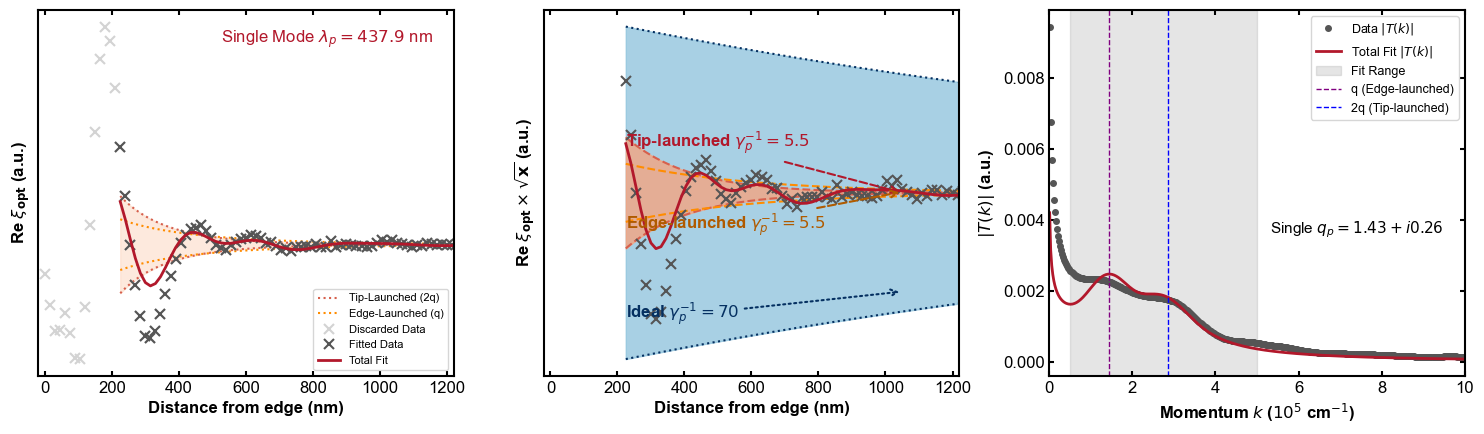

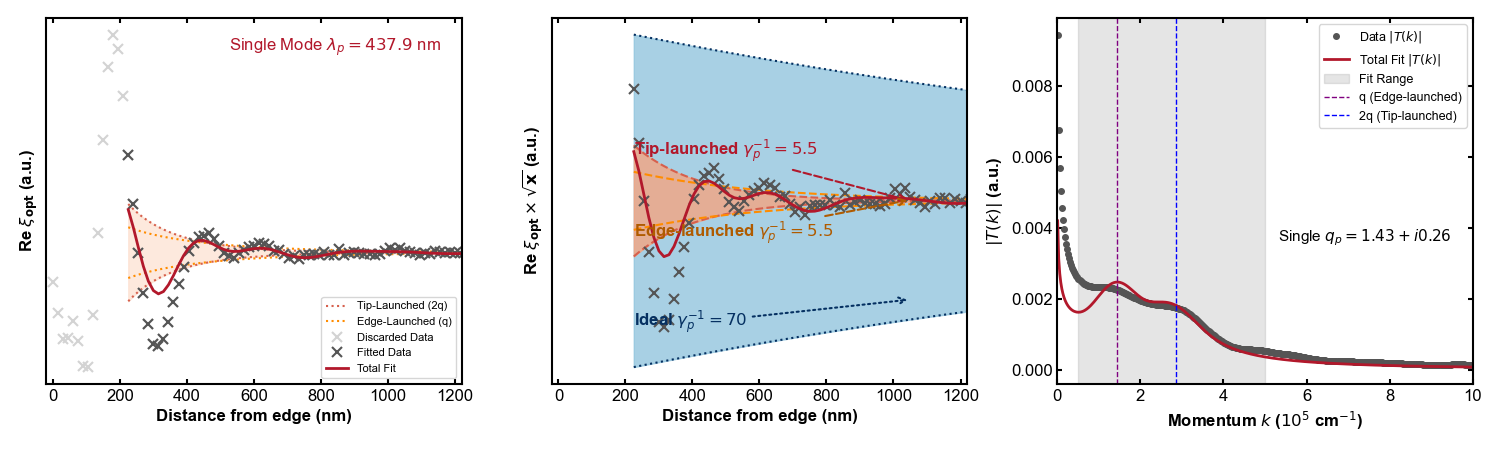

In [5]:
# === Tunable Parameters for CHT ===
x_start_cht = 0.22   
L_cutoff = 1.2       

# 🌟 Select your physical model!
# 'independent'  -> Fits N independent peaks (e.g. acoustic & optical plasmons)
# 'linked_paper' -> Fits exact paper equation: A*H0(2qx) + B*exp(iqx)/sqrt(x) based on a SINGLE qp
model_type = 'linked_paper'

# 🌟 ALL UNITS IN 10^5 cm^-1 (Same as the plots!)
k_fit_range_cm = (0.5, 5.0) 

# --- FOR 'independent' MODEL ONLY ---
num_peaks = 2        
k_peaks_guess_cm = [1.5, 3.0] 

# --- FOR 'linked_paper' MODEL ONLY ---
# Provide just ONE guess for the single plasmon momentum (the q_p position, NOT the 2q_p position).
# So if you see a bump at k=1.5 and a bump at k=3.0, enter 1.5!
k_linked_guess_cm = 1.5
# ==================================

# Convert inputs to um^-1 for the backend algorithm
k_fit_range = (k_fit_range_cm[0] * 10.0, k_fit_range_cm[1] * 10.0)

# Apply the optional left boundary cut
mask_cht = x_f >= x_start_cht
x_f_cht = x_f[mask_cht]
sig_f_cht = sig_f[mask_cht]

p0_guess = []
amp_max = np.nanmax(np.abs(sig_f_cht))

if model_type == 'independent':
    for i in range(num_peaks):
        k_cm = k_peaks_guess_cm[i] if i < len(k_peaks_guess_cm) else 2.0 * (i+1)
        q_re = (k_cm * 10.0) / 2.0  
        p0_guess.extend([amp_max / num_peaks, q_re, 0.5 + 0.2*i, 0.0])
elif model_type == 'linked_paper':
    q_re = (k_linked_guess_cm * 10.0) / 1.0  # single q_p guess! k_guess corresponds to 1*q_p here
    # p0 = [A, q_re, q_im, phase_A, B_amp, phase_B]
    p0_guess = [amp_max / 2.0, q_re, 0.5, 0.0, amp_max / 2.0, 0.0]

fit_params_cht, k_arr, T_data, T_mod, mod_sig_cplx = nanoftir.fit_cht_peaks(
    x_f_cht, sig_f_cht, L=L_cutoff, k_fit_range=k_fit_range, p0=p0_guess, k_plot_range=(0.1, 100), num_peaks=num_peaks, model_type=model_type
)

print(f"--- CHT Fit Results ({model_type}) ---")
envelope_list = []
x_safe = np.maximum(x_f_cht, 1e-5)
import scipy.special as sp

if model_type == 'independent':
    for i, params in enumerate(fit_params_cht):
        q_re_fit = params['q_re']
        q_im_fit = params['q_im']
        q_p = q_re_fit + 1j * q_im_fit
        lam_cht = (2 * np.pi / q_re_fit) * 1000
        damping_cht = q_re_fit / q_im_fit
        print(f"Peak {i+1}: k ≈ {2*q_re_fit/10.0:.2f} (10^5 cm^-1), Wavelength = {lam_cht:.1f} nm, Damping = {damping_cht:.1f}")
        env_i = params['A'] * np.abs(sp.hankel1(0, 2 * q_p * x_safe))
        envelope_list.append(env_i)
        
elif model_type == 'linked_paper':
    params = fit_params_cht[0]
    q_re_fit = params['q_re']
    q_im_fit = params['q_im']
    q_p = q_re_fit + 1j * q_im_fit
    lam_cht = (2 * np.pi / q_re_fit) * 1000
    damping_cht = q_re_fit / q_im_fit
    
    print(f"Single Plasmon Mode: q_p ≈ {q_re_fit/10.0:.2f} (10^5 cm^-1)")
    print(f"Wavelength = {lam_cht:.1f} nm, Damping = {damping_cht:.1f}")
    
    # Envelope 1: Tip-launched (2qp)
    env_tip = params['A'] * np.abs(sp.hankel1(0, 2 * q_p * x_safe))
    # Envelope 2: Edge-launched (qp)
    env_edge = params['B_amp'] * np.abs(np.exp(1j * q_p * x_safe) / np.sqrt(x_safe))
    
    envelope_list.append(env_tip)
    envelope_list.append(env_edge)

mod_sig_fit = np.real(mod_sig_cplx)
envelope = envelope_list[0] 

# ==========================================
# 📊 Plotting in Paper Style + k-space
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=100)

c_data = '#555555'  
c_fit = '#b2182b'   
c_env_a = '#fddbc7' 
c_env_b_blue = '#92c5de' 
c_env_b_red = '#f4a582'  
colors_peaks = ['#d6604d', 'darkorange', 'green']
colors_text = ['#b2182b', '#b05b00', 'darkgreen']
labels_linked = ['Tip-Launched (2q)', 'Edge-Launched (q)']

# Panel (a)
ax = axes[0]
x_nm = x_f_cht * 1000 
ax.fill_between(x_nm, envelope, -envelope, color=c_env_a, alpha=0.6)

num_envs = len(envelope_list)
for i in range(num_envs):
    lbl = labels_linked[i] if model_type == 'linked_paper' else f'Peak {i+1} Env'
    ax.plot(x_nm, envelope_list[i], color=colors_peaks[i % len(colors_peaks)], linestyle=':', lw=1.5, label=lbl)
    ax.plot(x_nm, -envelope_list[i], color=colors_peaks[i % len(colors_peaks)], linestyle=':', lw=1.5)

ax.plot(x_f * 1000, sig_f, marker='x', markersize=7, markeredgewidth=1.5, linestyle='None', color='lightgray', label='Discarded Data')
ax.plot(x_nm, sig_f_cht, marker='x', markersize=7, markeredgewidth=1.5, linestyle='None', color=c_data, label='Fitted Data')
ax.plot(x_nm, mod_sig_fit, color=c_fit, lw=2, label='Total Fit')
ax.set_xlabel('Distance from edge (nm)', fontweight='bold')
ax.set_ylabel(r'Re $\xi_{\mathbf{opt}}$ (a.u.)', fontweight='bold')
ax.set_xlim(-20, L_cutoff * 1000 + 20)
ax.set_yticks([])

if model_type == 'independent':
    for i in range(num_envs):
        q_re = fit_params_cht[i]['q_re']
        txt_a = rf"Peak {i+1} $\lambda_p = { (2 * np.pi / q_re) * 1000 :.1f}$ nm"
        ax.text(0.95, 0.95 - 0.08*i, txt_a, transform=ax.transAxes, fontsize=12, va='top', ha='right', color=colors_text[i % len(colors_text)])
elif model_type == 'linked_paper':
    q_re = fit_params_cht[0]['q_re']
    txt_a = rf"Single Mode $\lambda_p = { (2 * np.pi / q_re) * 1000 :.1f}$ nm"
    ax.text(0.95, 0.95, txt_a, transform=ax.transAxes, fontsize=12, va='top', ha='right', color=colors_text[0])

ax.legend(loc='lower right', fontsize=8)

# Panel (b)
ax = axes[1]
sqrt_x = np.sqrt(x_safe)
sig_fit_sqrt = sig_f_cht * sqrt_x
mod_sig_fit_sqrt = mod_sig_fit * sqrt_x
envelope_sqrt = envelope * sqrt_x

q_re_fit_1 = fit_params_cht[0]['q_re']
q_im_ideal = q_re_fit_1 / 70.0
q_p_ideal = q_re_fit_1 + 1j * q_im_ideal
envelope_ideal = fit_params_cht[0]['A'] * np.abs(sp.hankel1(0, 2 * q_p_ideal * x_safe))
envelope_sqrt_ideal = envelope_ideal * sqrt_x

ax.fill_between(x_nm, envelope_sqrt_ideal, -envelope_sqrt_ideal, color=c_env_b_blue, alpha=0.8)
ax.fill_between(x_nm, envelope_sqrt, -envelope_sqrt, color=c_env_b_red, alpha=0.8)
ax.plot(x_nm, envelope_sqrt_ideal, color='#053061', linestyle=':', lw=1.5)
ax.plot(x_nm, -envelope_sqrt_ideal, color='#053061', linestyle=':', lw=1.5)

for i in range(num_envs):
    env_sqrt_i = envelope_list[i] * sqrt_x
    ax.plot(x_nm, env_sqrt_i, color=colors_peaks[i % len(colors_peaks)], linestyle='--', lw=1.5)
    ax.plot(x_nm, -env_sqrt_i, color=colors_peaks[i % len(colors_peaks)], linestyle='--', lw=1.5)

ax.plot(x_nm, sig_fit_sqrt, marker='x', markersize=7, markeredgewidth=1.5, linestyle='None', color=c_data)
ax.plot(x_nm, mod_sig_fit_sqrt, color=c_fit, lw=2)

ax.set_xlabel('Distance from edge (nm)', fontweight='bold')
ax.set_ylabel(r'Re $\xi_{\mathbf{opt}} \times \sqrt{\mathbf{x}}$ (a.u.)', fontweight='bold')
ax.set_xlim(-20, L_cutoff * 1000 + 20)
ax.set_yticks([])

for i in range(num_envs):
    if model_type == 'independent':
        damping_cht_i = fit_params_cht[i]['q_re'] / fit_params_cht[i]['q_im']
        lbl = f"Peak {i+1}"
    else:
        damping_cht_i = fit_params_cht[0]['q_re'] / fit_params_cht[0]['q_im']
        lbl = "Tip-launched" if i == 0 else "Edge-launched"
        
    env_sqrt_i = envelope_list[i] * sqrt_x
    max_env = np.max(env_sqrt_i)
    y_pos = env_sqrt_i[-1] * 1.0
    y_text_offset = max_env * (0.8 + 0.5*i) if i % 2 == 0 else -max_env * (0.8 + 0.5*i)
    
    ax.annotate(rf"{lbl} $\gamma_p^{{-1}} = {damping_cht_i:.1f}$", 
                xy=(x_nm[-1]*0.7, y_pos),
                xytext=(x_nm[-1]*0.15, y_pos + y_text_offset),
                color=colors_text[i % len(colors_text)], fontsize=12, fontweight='bold',
                arrowprops=dict(arrowstyle="->", color=colors_text[i % len(colors_text)], lw=1.5, linestyle='--'))

ax.annotate(rf"Ideal $\gamma_p^{{-1}} = 70$", 
            xy=(x_nm[-1]*0.7, -envelope_sqrt_ideal[-1]*1.0),
            xytext=(x_nm[-1]*0.15, -envelope_sqrt_ideal[-1]*1.0 - 0.5 * np.max(envelope_sqrt)),
            color='#053061', fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='#053061', lw=1.5, linestyle=':'))

# Panel (c): k-space
ax = axes[2]
k_arr_cm = k_arr / 10.0
ax.plot(k_arr_cm, np.abs(T_data), 'o', color=c_data, markersize=4, label='Data $|T(k)|$')
ax.plot(k_arr_cm, np.abs(T_mod), '-', color=c_fit, lw=2, label='Total Fit $|T(k)|$')
ax.axvspan(k_fit_range_cm[0], k_fit_range_cm[1], color='gray', alpha=0.2, label='Fit Range')

k_colors = ['blue', 'purple', 'green']
if model_type == 'independent':
    for i, params in enumerate(fit_params_cht):
        k_peak_cm = (2 * params['q_re']) / 10.0
        ax.axvline(k_peak_cm, color=k_colors[i % len(k_colors)], linestyle='--', lw=1, label=f'Peak {i+1}')
        txt_c = rf"Peak {i+1}: $q_p = {params['q_re']/10.0:.2f} + i{params['q_im']/10.0:.2f}$"
        ax.text(0.95, 0.4 - 0.1*i, txt_c, transform=ax.transAxes, fontsize=11, va='center', ha='right', color=k_colors[i % len(k_colors)])
elif model_type == 'linked_paper':
    q_re = fit_params_cht[0]['q_re']
    q_im = fit_params_cht[0]['q_im']
    ax.axvline(q_re / 10.0, color='purple', linestyle='--', lw=1, label='q (Edge-launched)')
    ax.axvline(2 * q_re / 10.0, color='blue', linestyle='--', lw=1, label='2q (Tip-launched)')
    
    txt_c = rf"Single $q_p = {q_re/10.0:.2f} + i{q_im/10.0:.2f}$"
    ax.text(0.95, 0.4, txt_c, transform=ax.transAxes, fontsize=11, va='center', ha='right', color='black')

ax.set_xlabel(r'Momentum $k$ ($10^5$ cm$^{-1}$)', fontweight='bold')
ax.set_ylabel(r'$|T(k)|$ (a.u.)', fontweight='bold')
ax.set_xlim(0, 10)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
fig


## 3. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)
Using your `compare_cavity_models` wrapper. I have updated `nanoftir_Shizhe.py` to natively support `edges='single'`!
This means we no longer need to hack the boundary to infinity. We just pass `edges='single'` and it correctly fits only the left boundary launched wave.

hankel    q=1.38e+05 cm^-1  lambda=0.456 um  q_imag=3.635 um^-1 (3.63e+04 cm^-1)  a=None  rmse=0.07546  aic=-336.31
1/sqrtx   q=1.53e+05 cm^-1  lambda=0.411 um  alpha_env=5.643 um^-1 (5.64e+04 cm^-1)  a=None  rmse=0.09872  aic=-300.85


/opt/anaconda3/lib/python3.13/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  self.figure.savefig(buf, format='png', dpi='figure')


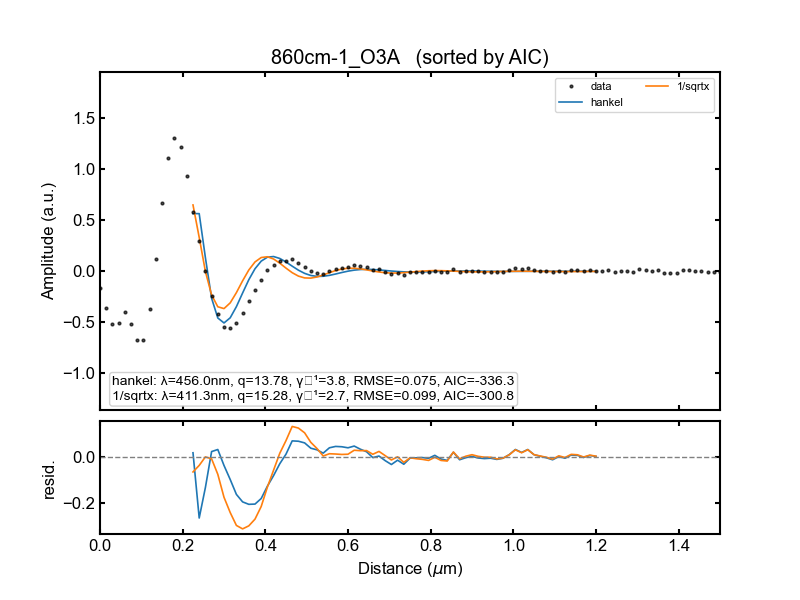

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


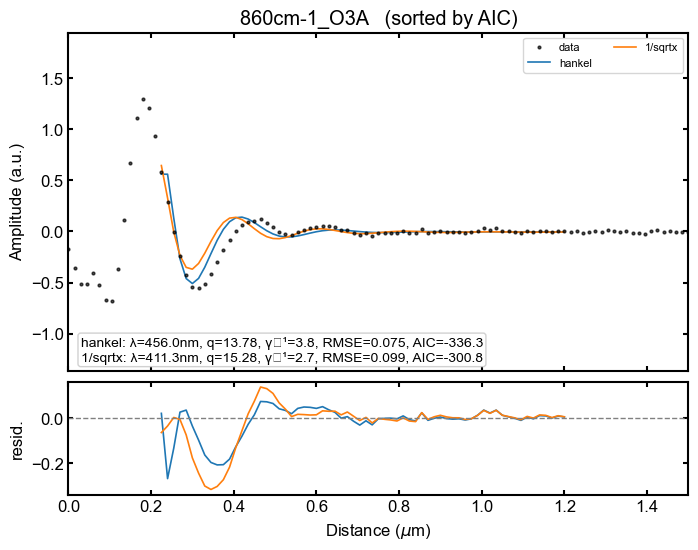

In [5]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    '860cm-1_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.22, 1.2)   # 🌟 BUG FIXED: x_f already starts at 0, so left edge must be 0!
win_size = 3            # Window size for smoothing before peak-finding (larger = smoother)
prominence = 0.01       # Prominence for peak finding
lam0_guess_um = 0.38   # Initial guess for wavelength
# ==============================================

# Call the wrapper with natively supported single-edge mode
outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, '860cm-1_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    xlim=(x_f.min(), x_f.max()),
    figsize=(8, 6)
)
plt.show()
fig
# Display the figure in the notebook

## 4. Standard FFT Analysis (Comparison)
Let's compare the CHT momentum-space peak with a standard 1D FFT using your `plot_channel_fft` function.

Running standard FFT comparison...


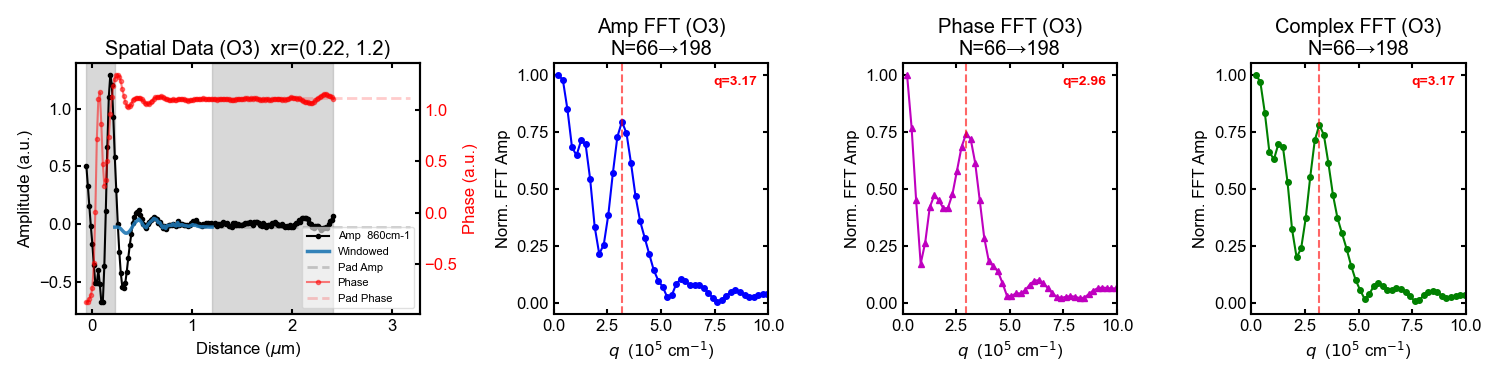

In [6]:
# === Standard 1D FFT Analysis ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import nanoftir_Shizhe as nanof
importlib.reload(nanof)

try:
    print("Running standard FFT comparison...")
    # Directly use the full aligned dataframe to prevent length mismatch bugs
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    # We subtract background here too to ensure FFT is analyzing pure oscillations
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    # 🌟 q_guess is exposed here! Adjust [5, 30] to search for peaks in different k regions.
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.22, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[3] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")
    traceback.print_exc()
